In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import seaborn as sns

In [3]:
df=pd.read_csv('Algerian_forest_fires_dataset_cleaned_set_1.csv')

In [4]:
df.head(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,not fire,0
1,2,6,2012,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,not fire,0
2,3,6,2012,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,not fire,0
3,4,6,2012,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,not fire,0


In [5]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='str')

In [6]:
#droping day,month,year
df.drop(['day', 'month', 'year'],axis=1,inplace=True)

In [7]:
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [8]:
df['Classes']

0      0
1      0
2      0
3      0
4      0
      ..
238    1
239    0
240    0
241    0
242    0
Name: Classes, Length: 243, dtype: int64

In [9]:
#independth and dependent features
x=df.drop("FWI",axis=1) #everything except fwi column
y=df['FWI']             #only FWI

In [10]:
x

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0,0
1,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0,0
2,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0,0
3,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0,0
4,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.0,16.0,44.0,4.0,16.0,1,1
239,28,87,15,4.0,41.0,6.0,8.0,0.0,6.0,0,1
240,27,87,29,0.0,45.0,3.0,7.0,0.0,3.0,0,1
241,24,54,18,0.0,79.0,4.0,15.0,1.0,5.0,0,1


In [11]:
y

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
238    6.0
239    0.0
240    0.0
241    0.0
242    0.0
Name: FWI, Length: 243, dtype: float64

In [12]:
df['FWI'].unique()

array([ 0.,  2.,  7.,  5.,  1.,  3.,  8., 10., 15., 13., 12.,  4.,  6.,
       11.,  9., 14., 16., 17., 18., 20., 22., 19., 30., 25., 21., 24.,
       26., 31.])

In [13]:
# here we will train test split the data accordingly to test and train
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [14]:
#now here we will do feature selection based upon corrleatoion
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.656095,-0.305977,-0.306038,0.695331,0.498175,0.390635,0.627053,0.472358,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.229973,-0.652678,-0.415250,-0.235899,-0.714926,-0.360375,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.254496,-0.188049,0.001659,0.096734,-0.025003,0.035080,-0.082570,-0.199969
Rain,-0.306038,0.229973,0.254496,1.000000,-0.499566,-0.254179,-0.275160,-0.299710,-0.268655,-0.319140,-0.044948
FFMC,0.695331,-0.652678,-0.188049,-0.499566,1.000000,0.620763,0.524165,0.742492,0.608335,0.780763,0.250205
DMC,0.498175,-0.415250,0.001659,-0.254179,0.620763,1.000000,0.868316,0.685493,0.983034,0.616216,0.210496
DC,0.390635,-0.235899,0.096734,-0.275160,0.524165,0.868316,1.000000,0.507149,0.941932,0.543436,-0.060266
ISI,0.627053,-0.714926,-0.025003,-0.299710,0.742492,0.685493,0.507149,1.000000,0.640555,0.738239,0.301688
BUI,0.472358,-0.360375,0.035080,-0.268655,0.608335,0.983034,0.941932,0.640555,1.000000,0.613871,0.115529
Classes,0.542141,-0.456876,-0.082570,-0.319140,0.780763,0.616216,0.543436,0.738239,0.613871,1.000000,0.188837


<Axes: >

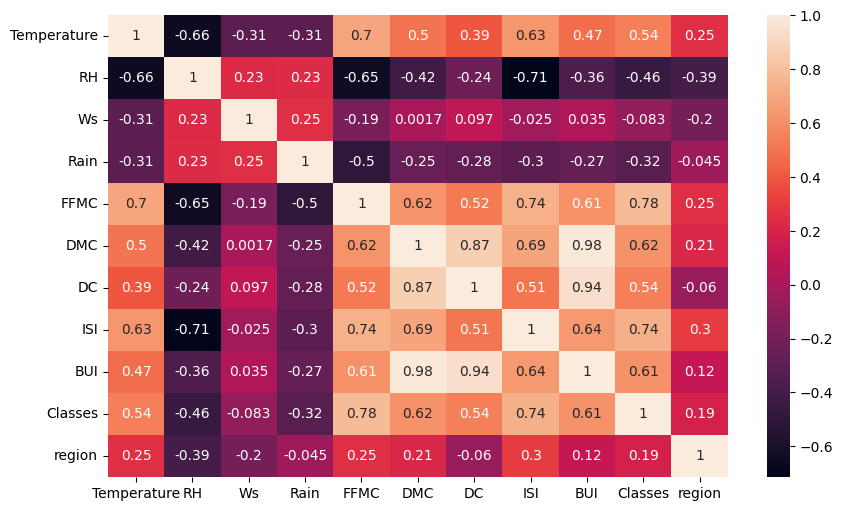

In [15]:
plt.figure(figsize=(10,6))
corr=x_train.corr()
sns.heatmap(corr,annot=True)

In [16]:
def correlation (dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i] 
                col_corr.add(colname)
    return col_corr

In [17]:
#setting up the threshuld to delete the features exceeding threshould
corr_feature=correlation(x_train,0.85)

In [18]:
corr_feature

{'BUI', 'DC'}

In [19]:
x_train.drop(corr_feature,axis=1,inplace=True)
x_test.drop(corr_feature,axis=1,inplace=True)
#so her basiclly the column which are highly co related are droped

In [20]:
x_train.shape,x_test.shape  #column droped

((182, 9), (61, 9))

In [21]:
#feature scalling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train) # here the fit calculates mean and sd
x_test_scaled=scaler.transform(x_test)

In [22]:
x_test_scaled

array([[-0.30175842,  0.11522353, -0.21905398, -0.32331979,  0.61223879,
        -0.01959019,  0.13757839,  0.90553851, -0.98907071],
       [ 0.23932564, -0.55263261, -0.9784411 , -0.32331979,  0.75161022,
        -0.41574739,  0.36942345,  0.90553851, -0.98907071],
       [-1.11338451, -0.28549015,  0.9200267 ,  0.65741691, -0.99053268,
        -0.89113604, -0.78980187, -1.10431526,  1.01105006],
       [ 0.50986767, -0.28549015, -0.9784411 , -0.32331979,  0.12443878,
         0.29733557, -0.5579568 , -1.10431526,  1.01105006],
       [-0.57230045,  0.18200914, -0.59874754, -0.32331979,  0.54255307,
         0.13887269, -0.09426667,  0.90553851,  1.01105006],
       [ 1.86257782,  0.11522353, -2.49721534,  0.16704856, -0.29367552,
        -0.25728451, -0.78980187, -1.10431526,  1.01105006],
       [-1.11338451,  0.84986528,  0.16063958, -0.32331979,  0.33349593,
        -0.8119046 , -0.32611174,  0.90553851,  1.01105006],
       [ 1.32149376, -1.75477365, -0.9784411 , -0.32331979,  0

Text(0.5, 1.0, 'X_train After Scaling')

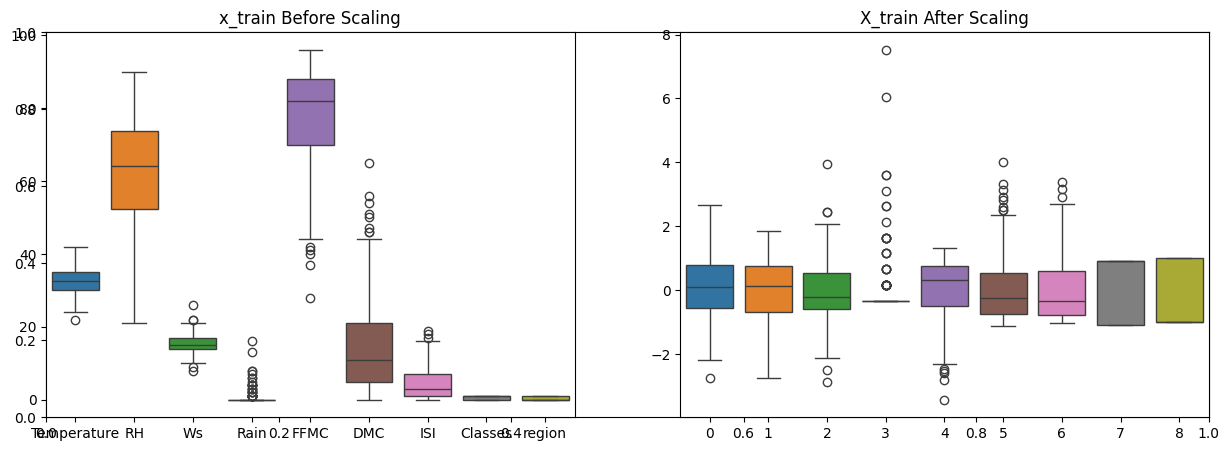

In [23]:
plt.subplots (figsize=(15,5))
plt.subplot(1, 2, 1)
sns.boxplot(data=x_train)
plt.title('x_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=x_train_scaled)
plt.title('X_train After Scaling')

linear regression model

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(x_train_scaled,y_train)
y_pred=linreg.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error  = ",mae)
print("R_square = ",score)

mean_absolute_error  =  0.6513439558787255
R_square =  0.9806173849583818


LASSO regression

In [25]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error  = ",mae)
print("R_square = ",score)

mean_absolute_error  =  1.258507588781346
R_square =  0.9420873245222859


In [26]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error  = ",mae)
print("R_square = ",score)

mean_absolute_error  =  0.6583310952992627
R_square =  0.9802774276038304


In [27]:
import pickle 
pickle.dump(ridge,open('ridge.pk1','wb'))#wb=write byte
ridge=pickle.load(open('ridge.pk1','rb'))

Elastic net

In [28]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
en=ElasticNet()
en.fit(x_train_scaled,y_train)
y_pred=en.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error  = ",mae)
print("R_square = ",score)

mean_absolute_error  =  1.9366743835956297
R_square =  0.8716490544669824


In [29]:
#cross validation
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(x_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [30]:
lassocv.predict(x_train_scaled)

array([ 9.41367653e-01, -1.37771402e+00,  2.10610131e+01,  3.17455374e+00,
        8.72194934e-01,  8.63234189e+00,  5.99900974e+00,  9.66662737e+00,
       -5.69438153e-01,  7.04443469e+00,  1.17098032e+01,  1.44837994e+01,
        1.19755542e+01, -5.87799072e-01,  9.78739491e-01, -6.15832160e-01,
        2.87535811e+00,  1.29911066e+01, -1.24137807e+00,  9.70200269e+00,
        5.34481586e+00,  6.65480702e+00,  9.55595541e+00,  2.88120629e+01,
        4.06085822e-01, -8.35844910e-01,  5.22130659e-01,  6.34163532e+00,
        5.07168224e+00,  3.51715385e+00, -1.05891188e+00,  7.24962851e-01,
        1.06301696e+00,  3.66534277e+00, -5.11162186e-01, -1.30662805e+00,
        1.88639431e+01,  3.63145409e+00,  9.31293334e-01,  1.33878151e+01,
        1.18753496e+01,  1.36038013e+01,  5.31369043e-01,  1.38932499e+01,
        1.25261569e+01,  3.55881483e+00,  4.70889550e-01,  2.48121930e+01,
        1.85513259e-01, -5.10201256e-01,  1.24460068e+01,  4.03315259e+00,
       -9.17829196e-01,  

In [31]:
lassocv.alpha_

np.float64(0.05319784709210762)

In [32]:
lassocv.alphas_

array([7.03244231, 6.55847923, 6.11645968, 5.70423077, 5.31978471,
       4.96124902, 4.62687744, 4.31504139, 4.02422204, 3.75300295,
       3.50006311, 3.26417057, 3.0441764 , 2.8390091 , 2.64766939,
       2.46922533, 2.30280781, 2.14760627, 2.00286479, 1.86787841,
       1.74198966, 1.62458538, 1.51509377, 1.41298152, 1.31775129,
       1.22893927, 1.14611287, 1.0688687 , 0.99683053, 0.92964749,
       0.86699236, 0.80855997, 0.75406574, 0.70324423, 0.65584792,
       0.61164597, 0.57042308, 0.53197847, 0.4961249 , 0.46268774,
       0.43150414, 0.4024222 , 0.37530029, 0.35000631, 0.32641706,
       0.30441764, 0.28390091, 0.26476694, 0.24692253, 0.23028078,
       0.21476063, 0.20028648, 0.18678784, 0.17419897, 0.16245854,
       0.15150938, 0.14129815, 0.13177513, 0.12289393, 0.11461129,
       0.10688687, 0.09968305, 0.09296475, 0.08669924, 0.080856  ,
       0.07540657, 0.07032442, 0.06558479, 0.0611646 , 0.05704231,
       0.05319785, 0.04961249, 0.04626877, 0.04315041, 0.04024

In [33]:
lassocv.mse_path_

array([[54.13235466, 65.08317897, 54.66409687, 79.43740748, 39.08312001],
       [47.02835498, 59.4801526 , 49.07719632, 77.61553268, 35.14026233],
       [41.20321847, 53.64320108, 42.30205002, 70.25676673, 31.69524509],
       [36.12888558, 47.86551754, 36.50256055, 63.77602031, 28.56472243],
       [31.70816192, 42.31146671, 31.54534281, 58.0643537 , 24.73580803],
       [27.85636734, 37.45255502, 27.31487079, 52.66557574, 21.42549312],
       [24.49979784, 33.19998413, 23.7109507 , 46.50233503, 18.56446544],
       [21.57450921, 29.47656604, 20.64698177, 41.11788719, 16.09372994],
       [19.02466618, 26.21504604, 18.04783899, 36.41224567, 13.9608985 ],
       [16.80174237, 23.35655918, 15.84841663, 32.29851317, 12.12087422],
       [14.86350672, 20.85057757, 13.99276209, 28.70100866, 10.53450745],
       [13.17313439, 18.65228107, 12.43213438, 25.55381321,  9.16781602],
       [11.69878702, 16.722855  , 11.12451188, 22.79900017,  7.99102329],
       [10.41254104, 15.02845546, 10.0

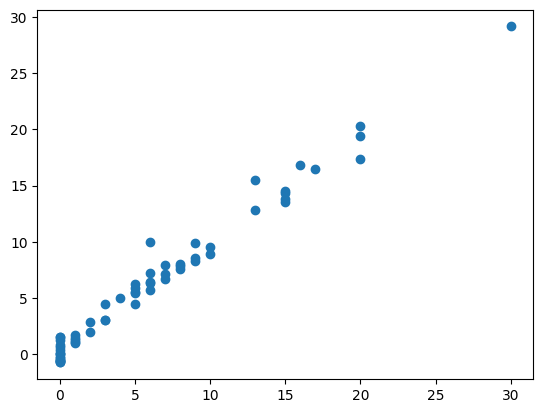

In [34]:
y_pred=lassocv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)

In [35]:
from sklearn.linear_model import RidgeCV